In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.covariance import LedoitWolf
from mcmc_core import run_hybrid_adaptive_mcmc

In [8]:
# ---------------------------------------------------------
# 1. prepare target summary statistics and covariance matrix
# ---------------------------------------------------------
obs_infected = pd.read_csv('data/infected_timeseries.csv')
obs_rewiring = pd.read_csv('data/rewiring_timeseries.csv')
obs_degrees = pd.read_csv('data/final_degree_histograms.csv')

peaks_per_rep = obs_infected.groupby('replicate_id')['infected_fraction'].max()
rewires_per_rep = obs_rewiring.groupby('replicate_id')['rewire_count'].sum()

obs_degrees['deg_x_count'] = obs_degrees['degree'] * obs_degrees['count']
obs_degrees['deg2_x_count'] = (obs_degrees['degree']**2) * obs_degrees['count']
mean_deg_per_rep = obs_degrees.groupby('replicate_id')['deg_x_count'].sum() / 200
var_deg_per_rep = obs_degrees.groupby('replicate_id')['deg2_x_count'].sum() / 200 - mean_deg_per_rep**2

idx_max_per_rep = obs_infected.groupby('replicate_id')['infected_fraction'].idxmax()
time_to_peak_per_rep = obs_infected.loc[idx_max_per_rep, 'time'].values

df_targets = pd.DataFrame({
    'peak': peaks_per_rep.values,
    'rewires': rewires_per_rep.values,
    'var_deg': var_deg_per_rep.values,
    'time': time_to_peak_per_rep
})

# ---------------------------------------------------------
# 2. Log-transform the target summary statistics
# ---------------------------------------------------------
df_targets_log = pd.DataFrame({
    'peak': peaks_per_rep.values,
    'log_rewires': np.log(rewires_per_rep.values),
    'log_var_deg': np.log(var_deg_per_rep.values),
    'log_time': np.log(time_to_peak_per_rep)
})

Checking Normality of Target Summary Statistics...
Saved normality check plots to: plots/target_normality_check_mcmc_1.pdf


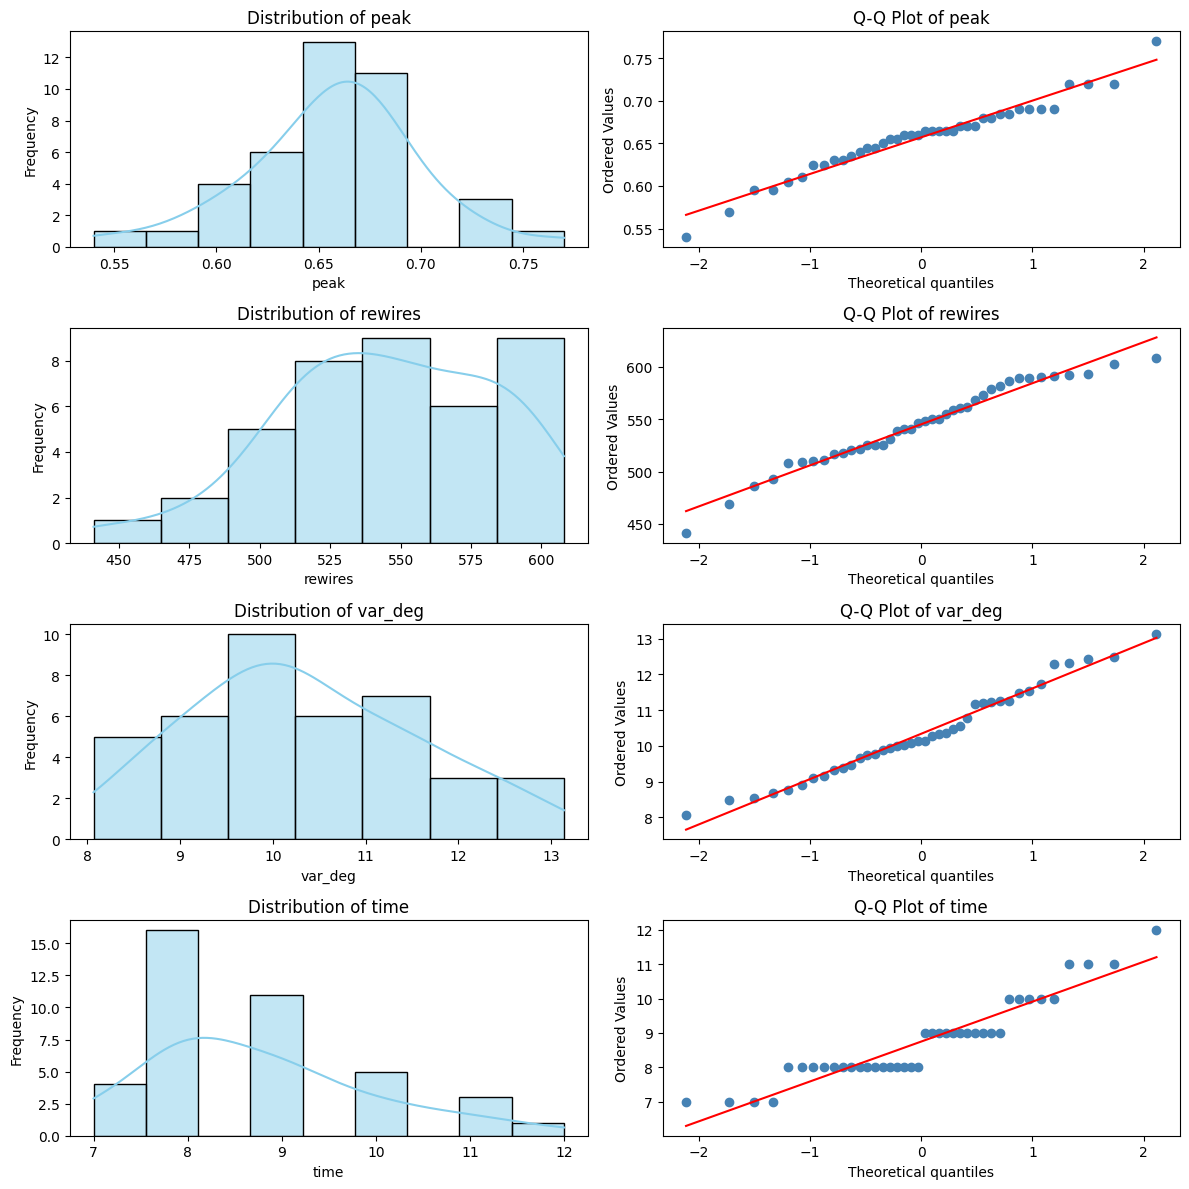

In [6]:
# ---------------------------------------------------------
# Check Normality of Summary Statistics (Histograms & Q-Q Plots)
# ---------------------------------------------------------
from scipy import stats


print("Checking Normality of Target Summary Statistics...")

# df_targets contains the 4 summary statistics for the 40 replicates
stats_names = ['peak', 'rewires', 'var_deg', 'time']
n_stats = len(stats_names)

fig, axes = plt.subplots(n_stats, 2, figsize=(12, 3 * n_stats))

for i, stat in enumerate(stats_names):
    data = df_targets[stat].values
    
    # 1. Histogram with KDE (Left column)
    sns.histplot(data, kde=True, ax=axes[i, 0], color='skyblue', edgecolor='black')
    axes[i, 0].set_title(f'Distribution of {stat}')
    axes[i, 0].set_xlabel(stat)
    axes[i, 0].set_ylabel('Frequency')
    
    # 2. Q-Q Plot (Right column)
    stats.probplot(data, dist="norm", plot=axes[i, 1])
    axes[i, 1].set_title(f'Q-Q Plot of {stat}')
    axes[i, 1].get_lines()[0].set_markerfacecolor('steelblue')
    axes[i, 1].get_lines()[0].set_markeredgecolor('steelblue')

plt.tight_layout()

# Save the plot
if not os.path.exists('plots'):
    os.makedirs('plots')
normality_plot_path = 'plots/target_normality_check_mcmc_1.pdf'
plt.savefig(normality_plot_path, format='pdf', bbox_inches='tight')
print(f"Saved normality check plots to: {normality_plot_path}")

plt.show()

Checking Normality of Log-Transformed Target Summary Statistics...
Saved log-transformed normality check plots to: plots/log_target_normality_check_mcmc_1.pdf


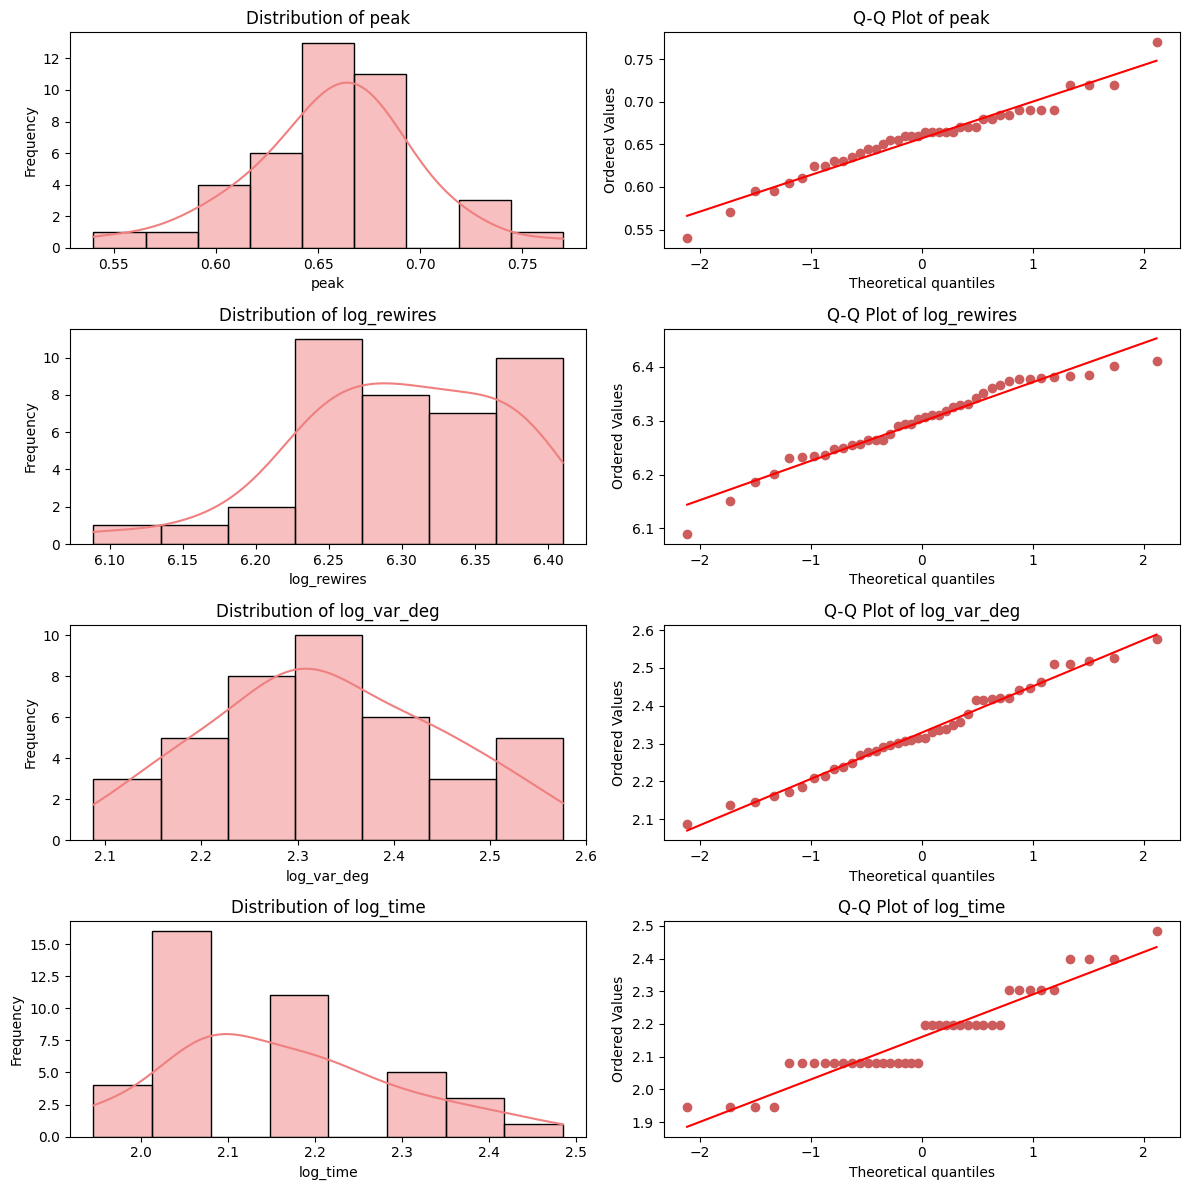

In [9]:
# ---------------------------------------------------------
# Check Normality of Log-Transformed Summary Statistics (Histograms & Q-Q Plots)
# ---------------------------------------------------------

print("Checking Normality of Log-Transformed Target Summary Statistics...")
log_stats_names = ['peak', 'log_rewires', 'log_var_deg', 'log_time']
n_log_stats = len(log_stats_names)
fig, axes = plt.subplots(n_log_stats, 2, figsize=(12, 3 * n_log_stats))
for i, stat in enumerate(log_stats_names):
    data = df_targets_log[stat].values
    
    # 1. Histogram with KDE (Left column)
    sns.histplot(data, kde=True, ax=axes[i, 0], color='lightcoral', edgecolor='black')
    axes[i, 0].set_title(f'Distribution of {stat}')
    axes[i, 0].set_xlabel(stat)
    axes[i, 0].set_ylabel('Frequency')
    
    # 2. Q-Q Plot (Right column)
    stats.probplot(data, dist="norm", plot=axes[i, 1])
    axes[i, 1].set_title(f'Q-Q Plot of {stat}')
    axes[i, 1].get_lines()[0].set_markerfacecolor('indianred')
    axes[i, 1].get_lines()[0].set_markeredgecolor('indianred')
plt.tight_layout()
log_normality_plot_path = 'plots/log_target_normality_check_mcmc_1.pdf'
plt.savefig(log_normality_plot_path, format='pdf', bbox_inches='tight')
print(f"Saved log-transformed normality check plots to: {log_normality_plot_path}")
plt.show()

In [3]:
# ---------------------------------------------------------
# 2. Ledoit-Wolf Shrinkage Covariance Estimation
# ---------------------------------------------------------
target_mu = df_targets.mean().values
X_targets = df_targets.values

lw = LedoitWolf()
lw.fit(X_targets)
target_cov_stable = lw.covariance_

print("Stable Target Covariance:\n", target_cov_stable)

Stable Target Covariance:
 [[ 2.22733108e+01 -6.84387655e-01 -6.49138531e-03 -1.80440195e-02]
 [-6.84387655e-01  1.38793927e+03  1.26333032e+01  2.72156626e+01]
 [-6.49138531e-03  1.26333032e+01  2.36815512e+01  2.02858789e-01]
 [-1.80440195e-02  2.72156626e+01  2.02858789e-01  2.35743347e+01]]


In [4]:
# ---------------------------------------------------------
# 3. Hybrid Two-Stage MCMC Sampling
# ---------------------------------------------------------
np.random.seed(100)  # For reproducibility

init_params = np.array([0.25, 0.10, 0.40])
init_proposal_cov = np.diag([0.05**2, 0.02**2, 0.1**2])

# stage schedules
mcmc_stages = [
    {'name': 'Phase 1 (Exploration)', 'iters': 5000, 'n_sim': 1, 'inflation': 4.0},
    {'name': 'Phase 2 (Final Sampling)', 'iters': 10000, 'n_sim': 10, 'inflation': 1.0}
]

# Run the hybrid adaptive MCMC
final_chain = run_hybrid_adaptive_mcmc(
    init_params=init_params, 
    target_mu=target_mu, 
    target_cov=target_cov_stable, 
    stages=mcmc_stages, 
    init_proposal_cov=init_proposal_cov
)


--- Starting Phase 1 (Exploration) ---
Iter: 1000/5000 | Acceptance Rate: 35.80%
Iter: 2000/5000 | Acceptance Rate: 34.50%
Iter: 3000/5000 | Acceptance Rate: 34.60%
Iter: 4000/5000 | Acceptance Rate: 35.27%
Phase 1 (Exploration) completed in 6.6 seconds.
Final Acceptance Rate: 35.92%

--- Starting Phase 2 (Final Sampling) ---
Iter: 1000/10000 | Acceptance Rate: 17.60%
Iter: 2000/10000 | Acceptance Rate: 17.10%
Iter: 3000/10000 | Acceptance Rate: 17.43%
Iter: 4000/10000 | Acceptance Rate: 18.20%
Iter: 5000/10000 | Acceptance Rate: 18.08%
Iter: 6000/10000 | Acceptance Rate: 17.98%
Iter: 7000/10000 | Acceptance Rate: 17.77%
Iter: 8000/10000 | Acceptance Rate: 17.90%
Iter: 9000/10000 | Acceptance Rate: 17.57%
Phase 2 (Final Sampling) completed in 72.5 seconds.
Final Acceptance Rate: 17.61%



Generating Pairwise Plots from Final Phase...
Saved MCMC pairplot to: plots/posterior_pairplot_mcmc_1.pdf


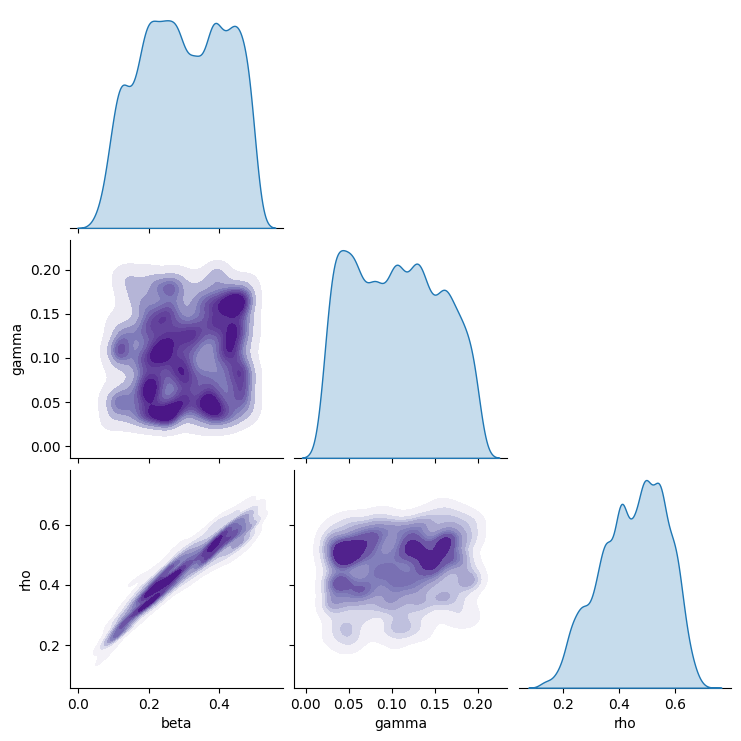

In [5]:
# ---------------------------------------------------------
# 4. Posterior Analysis and Visualization
# ---------------------------------------------------------
df_posterior = pd.DataFrame(final_chain, columns=['beta', 'gamma', 'rho'])

print("\nGenerating Pairwise Plots from Final Phase...")
g = sns.pairplot(df_posterior, kind='kde', corner=True, 
                plot_kws={'fill': True, 'cmap': 'Purples'}) 

if not os.path.exists('plots'):
    os.makedirs('plots')
    
pairplot_path = 'plots/posterior_pairplot_mcmc_1.pdf'
g.savefig(pairplot_path, format='pdf', bbox_inches='tight')
print(f"Saved MCMC pairplot to: {pairplot_path}")

plt.show()